In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

In [75]:
df = pd.read_csv("vgsales.csv")

In [76]:
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


## **Check Data Types**

In [77]:
df.dtypes

,0
Rank,int64
Name,object
Platform,object
Year,float64
Genre,object
Publisher,object
NA_Sales,float64
EU_Sales,float64
JP_Sales,float64
Other_Sales,float64


data type matches the real meaning of each column.

# **Detect Missing Values**

In [78]:
df.isna()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
16593,False,False,False,False,False,False,False,False,False,False,False
16594,False,False,False,False,False,False,False,False,False,False,False
16595,False,False,False,False,False,False,False,False,False,False,False
16596,False,False,False,False,False,False,False,False,False,False,False


In [79]:
df.isna().sum()

,0
Rank,0
Name,0
Platform,0
Year,271
Genre,0
Publisher,58
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0


# **The Median Imputation Strategy**

In [80]:
df['Year'] = df['Year'].fillna(df['Year'].median())

In [81]:
df.head(10)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,6,Tetris,GB,1989.0,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,7,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
7,8,Wii Play,Wii,2006.0,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02
8,9,New Super Mario Bros. Wii,Wii,2009.0,Platform,Nintendo,14.59,7.06,4.70,2.26,28.62
9,10,Duck Hunt,NES,1984.0,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31


In [82]:
df.isnull().sum()

,0
Rank,0
Name,0
Platform,0
Year,0
Genre,0
Publisher,58
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0


I applied Strategy 3: Median Imputation to handle missing values in the "Year" column because it is a numerical variable and may contain outliers. The median is more robust than the mean and provides a realistic value for missing years.

This strategy was not applied to the "Publisher" column because it is a categorical variable, and median imputation is not suitable for non-numerical data.

# Handling Outliers using IQR






In [83]:
import matplotlib.pyplot as plt

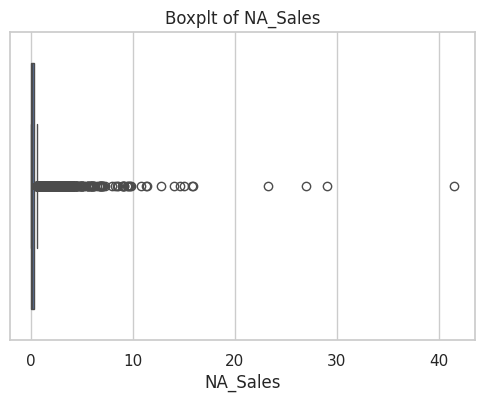

In [84]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['NA_Sales'])

plt.title('Boxplt of NA_Sales')
plt.show()

In [85]:
Q1 = df['NA_Sales'].quantile(0.25)
Q3 = df['NA_Sales'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['NA_Sales'] < lower) | (df['NA_Sales'] > upper)]
outliers.head(15)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,6,Tetris,GB,1989.0,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,7,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
7,8,Wii Play,Wii,2006.0,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02
8,9,New Super Mario Bros. Wii,Wii,2009.0,Platform,Nintendo,14.59,7.06,4.70,2.26,28.62
9,10,Duck Hunt,NES,1984.0,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31


In [86]:
df_no_outliers = df[(df['NA_Sales'] >= lower) & (df['NA_Sales'] <= upper)]

print('df with outliers: ',df.shape)
print('df without outliers: ',df_no_outliers.shape)

df with outliers:  (16598, 11)
df without outliers:  (14917, 11)


# **Data Transformation – Normalization & Z-Score Normalization**

In [87]:
df[['NA_Sales','EU_Sales']].head()

,NA_Sales,EU_Sales
0,41.49,29.02
1,29.08,3.58
2,15.85,12.88
3,15.75,11.01
4,11.27,8.89


In [88]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_scaled = df[['NA_Sales', 'EU_Sales']].copy()

df_scaled[['NA_Sales', 'EU_Sales']] = scaler.fit_transform(df_scaled)

df_scaled.head()

,NA_Sales,EU_Sales
0,1.000000,1.000000
1,0.700892,0.123363
2,0.382020,0.443832
3,0.379610,0.379394
4,0.271632,0.306340


In [90]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_standardized = df[['NA_Sales', 'EU_Sales']].copy()

df_standardized[['NA_Sales', 'EU_Sales']] = scaler.fit_transform(df[['NA_Sales', 'EU_Sales']])

df_standardized.head()

,NA_Sales,EU_Sales
0,50.480508,57.136930
1,35.284437,6.794188
2,19.084273,25.197785
3,18.961823,21.497277
4,13.476053,17.302048


# **Check Correlation Before Applying PCA**

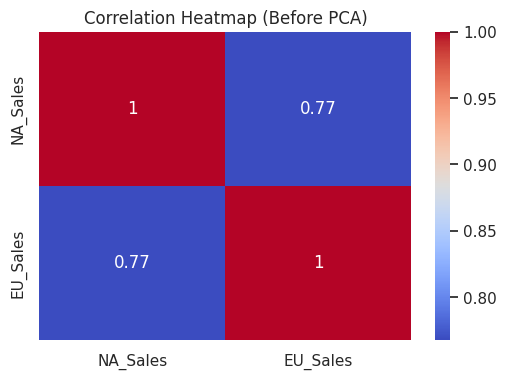

In [93]:
plt.figure(figsize=(6,4))
sns.heatmap(df_standardized[['NA_Sales', 'EU_Sales']].corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Before PCA)")
plt.show()

# **Applying PCA**

In [94]:
from sklearn.decomposition import PCA

X = df_standardized[['NA_Sales', 'EU_Sales']]

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.88386337 0.11613663]


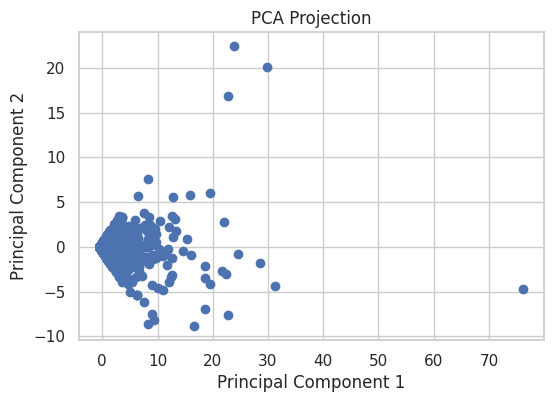

In [95]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()